In [51]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from scipy import stats
import numpy as np
from sklearn.metrics import mean_squared_error

In [33]:
crime = pd.read_csv("crime-housing-austin-2015.csv")

In [3]:
crime.columns

Index(['Key', 'Council_District', 'Highest_Offense_Desc',
       'Highest_NIBRS_UCR_Offense_Description', 'Report_Date', 'Location',
       'Clearance_Status', 'Clearance_Date', 'District', 'Zip_Code_Crime',
       'Census_Tract', 'X_Coordinate', 'Y_Coordinate', 'Zip_Code_Housing',
       'Populationbelowpovertylevel', 'Medianhouseholdincome',
       'Non-WhiteNon-HispanicorLatino', 'HispanicorLatinoofanyrace',
       'Populationwithdisability', 'Unemployment',
       'Largehouseholds(5+members)',
       'Homesaffordabletopeopleearninglessthan$50000',
       'Rentalsaffordabletopeopleearninglessthan$25000',
       'Rent-restrictedunits', 'HousingChoiceVoucherholders', 'Medianrent',
       'Medianhomevalue', 'Percentageofrentalunitsinpoorcondition',
       'Percentchangeinnumberofhousingunits2000-2012',
       'Ownerunitsaffordabletoaverageretail/serviceworker',
       'Rentalunitsaffordabletoaverageretail/serviceworker',
       'Rentalunitsaffordabletoaverageartist',
       'Ownerunits

In [ ]:
crime.groupby('Zip_Code_Crime').Medianhomevalue.unique()
crime.groupby('Zip_Code_Crime').Unemployment.unique()
crime.groupby('Zip_Code_Crime').Rentalunitsaffordabletoaverageartist.unique()

In [ ]:
crime.groupby('Census_Tract').Medianhomevalue.unique()
crime.groupby('Census_Tract').Unemployment.unique()
crime.groupby('Census_Tract').Rentalunitsaffordabletoaverageartist.unique()

In [ ]:
crime.groupby('Council_District').Medianhomevalue.unique()
crime.groupby('Council_District').Unemployment.unique()
crime.groupby('Council_District').Rentalunitsaffordabletoaverageartist.unique()

In [ ]:
crime.groupby('District').Medianhomevalue.unique()
crime.groupby('District').Unemployment.unique()
crime.groupby('District').Rentalunitsaffordabletoaverageartist.unique()

In [10]:
crime.Highest_Offense_Desc.unique()

<StringArray>
[     'AGG ROBBERY/DEADLY WEAPON',             'ROBBERY BY ASSAULT',
          'BURGLARY OF RESIDENCE',         'BURGLARY NON RESIDENCE',
                     'AUTO THEFT', 'AGG ASLT W/MOTOR VEH FAM/DAT V',
    'AGG ASLT STRANGLE/SUFFOCATE',                    'AGG ASSAULT',
 'AGG ASLT ENHANC STRANGL/SUFFOC',              'THEFT FROM PERSON',
           'THEFT BY SHOPLIFTING',            'BURGLARY OF VEHICLE',
                           'RAPE',         'THEFT OF LICENSE PLATE',
            'THEFT OF AUTO PARTS',                          'THEFT',
    'BREACH OF COMPUTER SECURITY',       'BURG NON RESIDENCE SHEDS',
                 'DEADLY CONDUCT',  'AGG ASSAULT FAM/DATE VIOLENCE',
            'THEFT FROM BUILDING',                'THEFT FROM AUTO',
         'THEFT OF VEHICLE/OTHER',       'THEFT OF HEAVY EQUIPMENT',
            'AGG RAPE OF A CHILD',                       'AGG RAPE',
                 'THEFT OF METAL',               'THEFT OF BICYCLE',
    'BURGLARY OF COI

C:\Users\dtree\AppData\Local\Temp\ipykernel_23072\933572876.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Violent Crimes", "Nonviolent Crimes"])


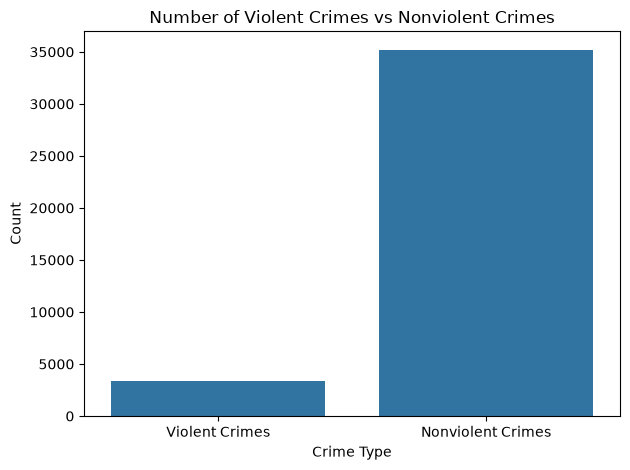

In [45]:
crime['violent_crime'] = crime.Highest_Offense_Desc.isin(['AGG ROBBERY/DEADLY WEAPON','ROBBERY BY ASSAULT','AGG ASLT W/MOTOR VEH FAM/DAT V',
    'AGG ASLT STRANGLE/SUFFOCATE','AGG ASSAULT','AGG ASLT ENHANC STRANGL/SUFFOC','RAPE','DEADLY CONDUCT','AGG ASSAULT FAM/DATE VIOLENCE',
    'AGG RAPE OF A CHILD','AGG RAPE','ROBBERY BY THREAT','AGG ROBBERY BY ASSAULT','RAPE OF A CHILD','AGG ASSAULT WITH MOTOR VEH','MURDER',
    'AGG ASSAULT ON PUBLIC SERVANT','BURG OF RES - SEXUAL NATURE', 'DEADLY CONDUCT FAM/DATE VIOL','TAKE WEAPON FRM POLICE OFFICER',
    'MANSLAUGHTER'])

crime['violent_crime_string'] = crime['violent_crime'].astype('string')

ax = sns.countplot(x="violent_crime_string", data=crime)
ax.set_xticklabels(["Violent Crimes", "Nonviolent Crimes"])
ax.set_ylabel("Count")
ax.set_title("Number of Violent Crimes vs Nonviolent Crimes")
ax.set_xlabel("Crime Type")

plt.tight_layout()
plt.show()

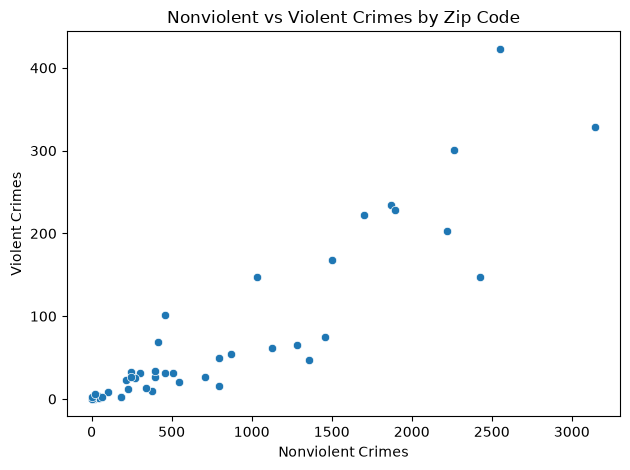

In [43]:
crime_by_zip = crime.groupby('Zip_Code_Crime')['violent_crime_string'].value_counts().unstack(fill_value=0)

ax = sns.scatterplot(x = 'False', y = 'True', data = crime_by_zip)

# ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_title("Nonviolent vs Violent Crimes by Zip Code")
ax.set_xlabel("Nonviolent Crimes")
ax.set_ylabel("Violent Crimes")

plt.tight_layout()
plt.show()

In [46]:
stats.pearsonr(crime_by_zip['False'], crime_by_zip['True'])

PearsonRResult(statistic=np.float64(0.9038699419011682), pvalue=np.float64(3.3184793879241316e-18))

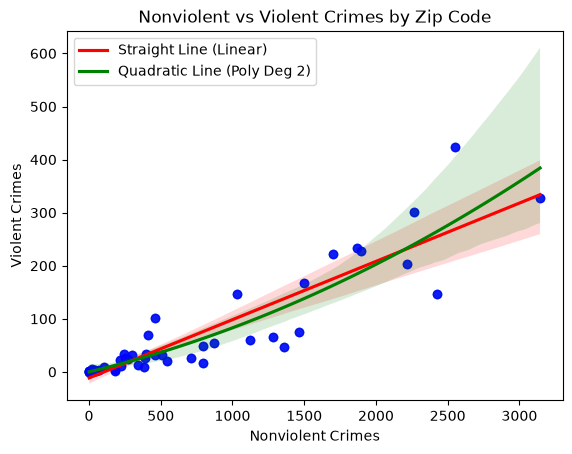

Straight Line RMSE: 42.2100
Quadratic Line RMSE: 40.4491


In [ ]:
sns.regplot(x = 'False', y = 'True', data = crime_by_zip,
    order=1,
    # label="Straight Line (Linear)",
    line_kws={"color": "red", "label": "Straight Line (Linear)"}
)

# Curved (Quadratic) Line -> order=2
sns.regplot(x = 'False', y = 'True', data = crime_by_zip,
    order=2,
    # label="Quadratic Line (Poly Deg 2)",
    scatter_kws={"color": "blue"},
    line_kws={"color": "green", "label": "Quadratic Line (Poly Deg 2)"},
)

plt.title("Nonviolent vs Violent Crimes by Zip Code")
plt.xlabel("Nonviolent Crimes")
plt.ylabel("Violent Crimes")
plt.legend()
plt.show()

coef_lin = np.polyfit(crime_by_zip["False"], crime_by_zip["True"], 1)  # degree = 1
pred_lin = np.polyval(coef_lin, crime_by_zip["False"])
rmse_lin = np.sqrt(mean_squared_error(crime_by_zip["True"], pred_lin))


coef_quad = np.polyfit(crime_by_zip["False"], crime_by_zip["True"], 2)  # degree = 2
pred_quad = np.polyval(coef_quad, crime_by_zip["False"])
rmse_quad = np.sqrt(mean_squared_error(crime_by_zip["True"], pred_quad))

print(f"Straight Line RMSE: {rmse_lin:.4f}")
print(f"Quadratic Line RMSE: {rmse_quad:.4f}")


The quadratic line fits slightly better, and the line shows that zip codes with more crime tend to have a higher ratio of violent crime. This effect isn't very large, but it does have theoretical backing.